# OLAP Analytics — ChurnCube
Slice-and-dice churn rates across key business dimensions: contract type, tenure cohort, payment method, and internet service type.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from pathlib import Path

OLAP_DIR = Path('../outputs/olap')
OLAP_DIR.mkdir(parents=True, exist_ok=True)

sns.set_style('whitegrid')
CHURN_COLOR = '#e74c3c'
RETAIN_COLOR = '#2ecc71'

# Load raw parquet (unscaled, readable values for OLAP)
df = pd.read_parquet('../data/raw.parquet')
print(f'Loaded: {df.shape[0]:,} rows × {df.shape[1]} cols')

Loaded: 7,043 rows × 21 cols


## 1. Churn Rate by Contract Type

      Contract  ChurnRate  CustomerCount
Month-to-month  42.709677           3875
      One year  11.269518           1473
      Two year   2.831858           1695


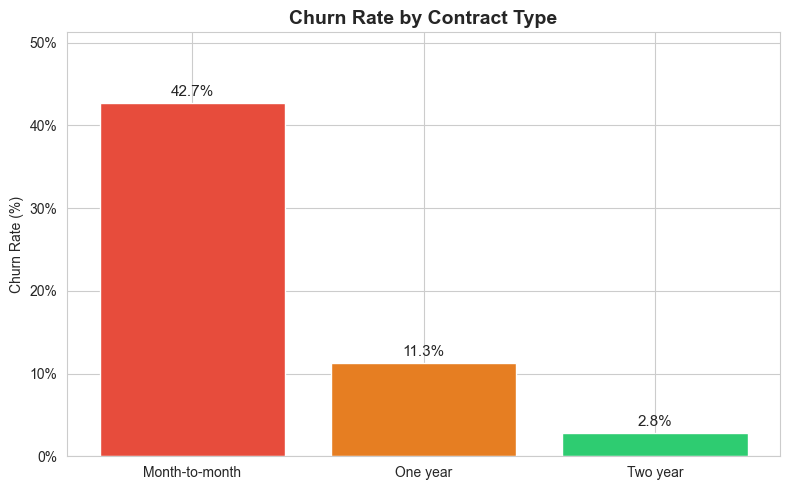

Saved → outputs/olap/churn_by_contract.png


In [2]:
contract_churn = (
    df.groupby('Contract')['Churn']
    .value_counts(normalize=True)
    .mul(100)
    .rename('Percentage')
    .reset_index()
)
contract_churn_rate = (
    df.groupby('Contract')['Churn']
    .apply(lambda x: (x == 'Yes').mean() * 100)
    .reset_index(name='ChurnRate')
    .sort_values('ChurnRate', ascending=False)
)
contract_churn_rate['CustomerCount'] = df.groupby('Contract').size().values
print(contract_churn_rate.to_string(index=False))
contract_churn_rate.to_csv(OLAP_DIR / 'churn_by_contract.csv', index=False)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(contract_churn_rate['Contract'], contract_churn_rate['ChurnRate'],
              color=[CHURN_COLOR, '#e67e22', RETAIN_COLOR])
ax.bar_label(bars, fmt='%.1f%%', padding=3, fontsize=11)
ax.set_title('Churn Rate by Contract Type', fontsize=14, fontweight='bold')
ax.set_ylabel('Churn Rate (%)')
ax.set_ylim(0, contract_churn_rate['ChurnRate'].max() * 1.2)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
plt.tight_layout()
plt.savefig(OLAP_DIR / 'churn_by_contract.png', dpi=150)
plt.show()
print('Saved → outputs/olap/churn_by_contract.png')

## 2. Churn Rate by Tenure Cohort

TenureCohort  ChurnRate  CustomerCount
     0–12 mo  47.438243           2186
    13–24 mo  28.710938           1024
    25–48 mo  20.388959           1594
    49–72 mo   9.513176           2239


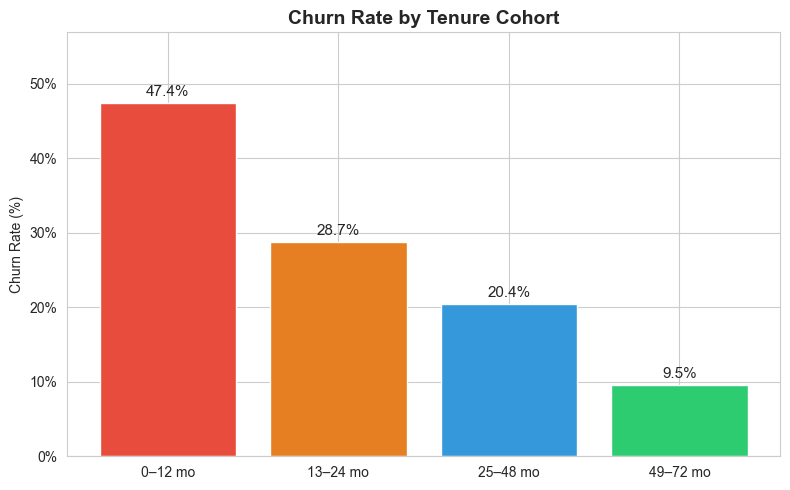

Saved → outputs/olap/churn_by_tenure_cohort.png


In [3]:
df['TenureCohort'] = pd.cut(
    df['tenure'],
    bins=[0, 12, 24, 48, 72],
    labels=['0–12 mo', '13–24 mo', '25–48 mo', '49–72 mo'],
    include_lowest=True
)

tenure_churn = (
    df.groupby('TenureCohort', observed=True)['Churn']
    .apply(lambda x: (x == 'Yes').mean() * 100)
    .reset_index(name='ChurnRate')
)
tenure_churn['CustomerCount'] = df.groupby('TenureCohort', observed=True).size().values
print(tenure_churn.to_string(index=False))
tenure_churn.to_csv(OLAP_DIR / 'churn_by_tenure_cohort.csv', index=False)

fig, ax = plt.subplots(figsize=(8, 5))
colors = [CHURN_COLOR, '#e67e22', '#3498db', RETAIN_COLOR]
bars = ax.bar(tenure_churn['TenureCohort'].astype(str), tenure_churn['ChurnRate'], color=colors)
ax.bar_label(bars, fmt='%.1f%%', padding=3, fontsize=11)
ax.set_title('Churn Rate by Tenure Cohort', fontsize=14, fontweight='bold')
ax.set_ylabel('Churn Rate (%)')
ax.set_ylim(0, tenure_churn['ChurnRate'].max() * 1.2)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
plt.tight_layout()
plt.savefig(OLAP_DIR / 'churn_by_tenure_cohort.png', dpi=150)
plt.show()
print('Saved → outputs/olap/churn_by_tenure_cohort.png')

## 3. Churn Rate by Payment Method

            PaymentMethod  ChurnRate  CustomerCount
         Electronic check  45.285412           2365
             Mailed check  19.106700           1612
Bank transfer (automatic)  16.709845           1544
  Credit card (automatic)  15.243101           1522


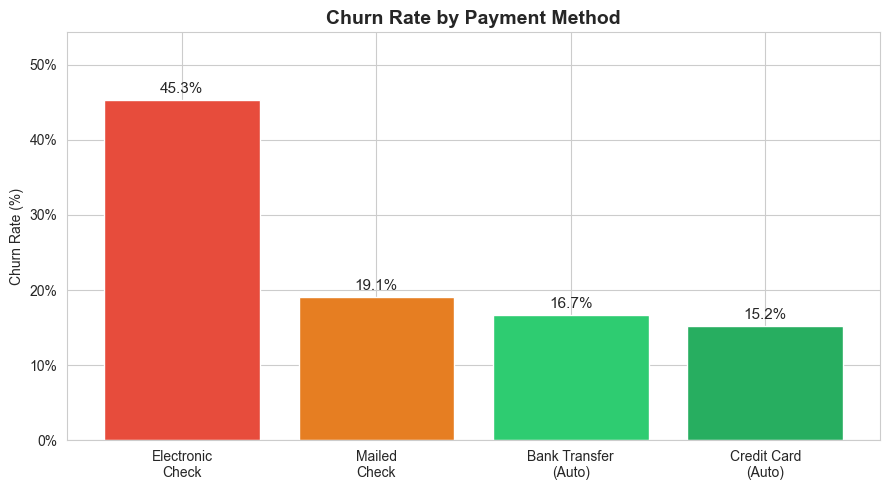

Saved → outputs/olap/churn_by_payment_method.png


In [4]:
payment_churn = (
    df.groupby('PaymentMethod')['Churn']
    .apply(lambda x: (x == 'Yes').mean() * 100)
    .reset_index(name='ChurnRate')
    .sort_values('ChurnRate', ascending=False)
)
payment_churn['CustomerCount'] = (
    df.groupby('PaymentMethod').size().reindex(payment_churn['PaymentMethod']).values
)
print(payment_churn.to_string(index=False))
payment_churn.to_csv(OLAP_DIR / 'churn_by_payment_method.csv', index=False)

# Shorten labels for chart
label_map = {
    'Electronic check': 'Electronic\nCheck',
    'Mailed check': 'Mailed\nCheck',
    'Bank transfer (automatic)': 'Bank Transfer\n(Auto)',
    'Credit card (automatic)': 'Credit Card\n(Auto)'
}
payment_churn['Label'] = payment_churn['PaymentMethod'].map(label_map)

fig, ax = plt.subplots(figsize=(9, 5))
colors = [CHURN_COLOR, '#e67e22', RETAIN_COLOR, '#27ae60']
bars = ax.bar(payment_churn['Label'], payment_churn['ChurnRate'], color=colors)
ax.bar_label(bars, fmt='%.1f%%', padding=3, fontsize=11)
ax.set_title('Churn Rate by Payment Method', fontsize=14, fontweight='bold')
ax.set_ylabel('Churn Rate (%)')
ax.set_ylim(0, payment_churn['ChurnRate'].max() * 1.2)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
plt.tight_layout()
plt.savefig(OLAP_DIR / 'churn_by_payment_method.png', dpi=150)
plt.show()
print('Saved → outputs/olap/churn_by_payment_method.png')

## 4. Churn Rate by Internet Service Type

InternetService  ChurnRate  CustomerCount
    Fiber optic  41.892765           3096
            DSL  18.959108           2421
             No   7.404980           1526


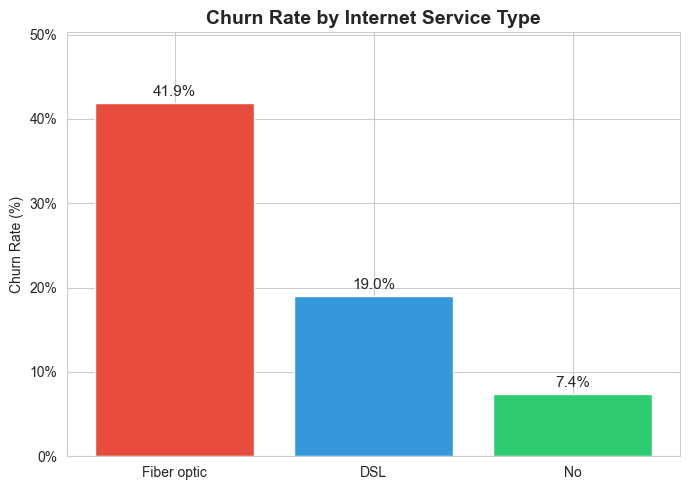

Saved → outputs/olap/churn_by_internet_service.png


In [5]:
internet_churn = (
    df.groupby('InternetService')['Churn']
    .apply(lambda x: (x == 'Yes').mean() * 100)
    .reset_index(name='ChurnRate')
    .sort_values('ChurnRate', ascending=False)
)
internet_churn['CustomerCount'] = (
    df.groupby('InternetService').size().reindex(internet_churn['InternetService']).values
)
print(internet_churn.to_string(index=False))
internet_churn.to_csv(OLAP_DIR / 'churn_by_internet_service.csv', index=False)

fig, ax = plt.subplots(figsize=(7, 5))
colors = [CHURN_COLOR, '#3498db', RETAIN_COLOR]
bars = ax.bar(internet_churn['InternetService'], internet_churn['ChurnRate'], color=colors)
ax.bar_label(bars, fmt='%.1f%%', padding=3, fontsize=11)
ax.set_title('Churn Rate by Internet Service Type', fontsize=14, fontweight='bold')
ax.set_ylabel('Churn Rate (%)')
ax.set_ylim(0, internet_churn['ChurnRate'].max() * 1.2)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
plt.tight_layout()
plt.savefig(OLAP_DIR / 'churn_by_internet_service.png', dpi=150)
plt.show()
print('Saved → outputs/olap/churn_by_internet_service.png')

## 5. Cross-Dimensional Heatmap: Contract × Internet Service

InternetService   DSL  Fiber optic    No
Contract                                
Month-to-month   32.2         54.6  18.9
One year          9.3         19.3   2.5
Two year          1.9          7.2   0.8


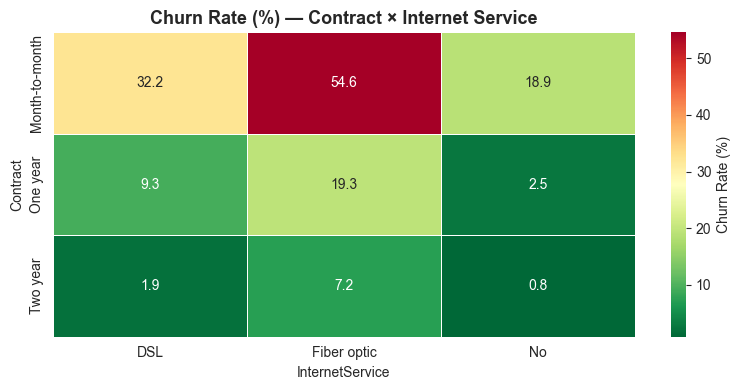

Saved → outputs/olap/churn_contract_x_internet_heatmap.png


In [6]:
cross_tab = (
    df.groupby(['Contract', 'InternetService'])['Churn']
    .apply(lambda x: (x == 'Yes').mean() * 100)
    .unstack('InternetService')
    .round(1)
)
print(cross_tab)
cross_tab.to_csv(OLAP_DIR / 'churn_contract_x_internet.csv')

fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(cross_tab, annot=True, fmt='.1f', cmap='RdYlGn_r',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Churn Rate (%)'})
ax.set_title('Churn Rate (%) — Contract × Internet Service', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OLAP_DIR / 'churn_contract_x_internet_heatmap.png', dpi=150)
plt.show()
print('Saved → outputs/olap/churn_contract_x_internet_heatmap.png')

## 6. OLAP Summary

In [7]:
print('=== OLAP ANALYTICS SUMMARY ===')
print()
print('Contract Type:')
for _, r in contract_churn_rate.iterrows():
    print(f'  {r["Contract"]:<20} {r["ChurnRate"]:.1f}%  (n={r["CustomerCount"]:,})')
print()
print('Tenure Cohort:')
for _, r in tenure_churn.iterrows():
    print(f'  {str(r["TenureCohort"]):<15} {r["ChurnRate"]:.1f}%  (n={r["CustomerCount"]:,})')
print()
print('Payment Method:')
for _, r in payment_churn.iterrows():
    print(f'  {r["PaymentMethod"]:<35} {r["ChurnRate"]:.1f}%  (n={r["CustomerCount"]:,})')
print()
print('Internet Service:')
for _, r in internet_churn.iterrows():
    print(f'  {r["InternetService"]:<15} {r["ChurnRate"]:.1f}%  (n={r["CustomerCount"]:,})')
print()
print('Output files:')
print('  outputs/olap/churn_by_contract.csv / .png')
print('  outputs/olap/churn_by_tenure_cohort.csv / .png')
print('  outputs/olap/churn_by_payment_method.csv / .png')
print('  outputs/olap/churn_by_internet_service.csv / .png')
print('  outputs/olap/churn_contract_x_internet.csv / heatmap.png')

=== OLAP ANALYTICS SUMMARY ===

Contract Type:
  Month-to-month       42.7%  (n=3,875)
  One year             11.3%  (n=1,473)
  Two year             2.8%  (n=1,695)

Tenure Cohort:
  0–12 mo         47.4%  (n=2,186)
  13–24 mo        28.7%  (n=1,024)
  25–48 mo        20.4%  (n=1,594)
  49–72 mo        9.5%  (n=2,239)

Payment Method:
  Electronic check                    45.3%  (n=2,365)
  Mailed check                        19.1%  (n=1,612)
  Bank transfer (automatic)           16.7%  (n=1,544)
  Credit card (automatic)             15.2%  (n=1,522)

Internet Service:
  Fiber optic     41.9%  (n=3,096)
  DSL             19.0%  (n=2,421)
  No              7.4%  (n=1,526)

Output files:
  outputs/olap/churn_by_contract.csv / .png
  outputs/olap/churn_by_tenure_cohort.csv / .png
  outputs/olap/churn_by_payment_method.csv / .png
  outputs/olap/churn_by_internet_service.csv / .png
  outputs/olap/churn_contract_x_internet.csv / heatmap.png
